# AdaGrad (Adaptive Gradient)

AdaGrad provides a way to normalize parameter updates by keeping a history of previous updates.
The bigger the sum of the updates is, in either direction (positive or negative), the smaller updates are made further in training. This lets less-frequently updated parameters to keep-up with changes, effectively utilizing more neurons for training.

```python
cache ​+= ​parm_gradient​ ** ​ 2 
parm_updates ​= ​learning_rate ​* ​parm_gradient / (sqrt(cache) ​+ eps) 
```

The​ `cache​` holds a history of squared gradients, and the ​`parm_updates​` is a function of the learning rate multiplied by the gradient (basic SGD so far) and then is divided by the square root of the `cache` plus some epsilon value (`eps`).

1. Gradient (current step):
$$
\underbrace{g_t}_{\text{parm\_gradient}} = \nabla_\theta J(\theta_t)
$$

2. Accumulate squared gradients (cache):
$$
\underbrace{G_t}_{\text{cache}} = \underbrace{G_{t-1}}_{\text{previous cache}} + \underbrace{g_t^2}_{\text{parm\_gradient ** 2}}
$$

3. Parameter update (normalized SGD step):
$$
\theta_{t+1} = \theta_t - 
\underbrace{\frac{\eta \, g_t}{\sqrt{G_t} + \epsilon}}_{\text{parm\_updates}}
$$

Where $\eta$ is the learning rate.

---

## Temporal Behavior of AdaGrad

### Early Training (small $t$)
- $G_{t,i}$ is small  
- Denominator $\sqrt{G_{t,i}} + \epsilon$ is small  
- Effective learning rate is large:

$$\eta_i^{(t)} = \frac{\eta}{\sqrt{G_{t,i}} + \epsilon}$$

**Result:** Large, aggressive parameter updates

### Mid Training
- $G_{t,i}$ accumulates over time  
- Denominator increases  
- Learning rate begins to shrink  

**Result:** More stable, controlled updates

### Late Training (large $t$)
- $G_{t,i}$ becomes large  
- $\eta_i^{(t)} \rightarrow 0$

**Result:** Very small updates means learning slows or stalls

In [20]:
# imports
import matplotlib.pyplot as plt
import numpy as np 
import math
import nnfs

from nnfs.datasets import spiral_data

In [18]:
class Optimizer_AdaGrad:
    def __init__(self, learning_rate=1.0, decay=0., epsilon=1e-7):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon

    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations))
    
    def update_params(self, layer):
        if not hasattr(layer, 'weight_cache'):
            # initialize vectors with zeros of similar -
            # shapes since weights/biases are vectors
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_cache = np.zeros_like(layer.biases)

        layer.weight_cache += layer.dweights ** 2
        layer.bias_cache += layer.dbiases ** 2

        layer.weights += -(self.current_learning_rate * layer.dweights) / (np.sqrt(layer.weight_cache) + self.epsilon)
        layer.biases += -(self.current_learning_rate * layer.dbiases) / (np.sqrt(layer.bias_cache) + self.epsilon)
    
    def post_update_params(self):
        self.iterations += 1

# Initialize Dense, ReLU, Loss

In [6]:
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

    def forward(self, inputs):
        self.inputs = inputs 
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        self.dinputs = np.dot(dvalues, self.weights.T)

class Activation_ReLU: 
    def forward(self, inputs): 
        self.inputs = inputs 
        self.output = np.maximum(0, inputs) 

    def backward(self, dvalues): 
        self.dinputs = dvalues.copy() 
        self.dinputs[self.inputs <= 0] = 0 

class Loss: 
    def calculate(self, output, y): 
        sample_losses = self.forward(output, y) 
        data_loss = np.mean(sample_losses) 
        return data_loss 
 
class Loss_CategoricalCrossentropy(Loss): 
    def forward(self, y_pred, y_true): 
        samples = len(y_pred) 
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7) 
        if len(y_true.shape) == 1: 
            correct_confidences = y_pred_clipped[ 
                range(samples), 
                y_true 
            ] 
        elif len(y_true.shape) == 2: 
            correct_confidences = np.sum( 
                y_pred_clipped * y_true, 
                axis=1 
            ) 
 
        negative_log_likelihoods = -np.log(correct_confidences) 
        return negative_log_likelihoods 
 
    def backward(self, dvalues, y_true): 
        samples = len(dvalues) 
        labels = len(dvalues[0]) 

        if len(y_true.shape) == 1: 
            y_true = np.eye(labels)[y_true] 
 
        self.dinputs = -y_true / dvalues 
        self.dinputs = self.dinputs / samples 

class Activation_Softmax: 
    def forward(self, inputs): 
        self.inputs = inputs 
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True)) 
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True) 
        self.output = probabilities 

    def backward(self, dvalues): 
        self.dinputs = np.empty_like(dvalues) 
 
        for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)): 
            single_output = single_output.reshape(-1, 1) 
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T) 

            self.dinputs[index] = np.dot(jacobian_matrix, 
                                         single_dvalues) 
 
class Activation_Softmax_Loss_CategoricalCrossentropy(): 
    def __init__(self): 
        self.activation = Activation_Softmax() 
        self.loss = Loss_CategoricalCrossentropy() 
 
    def forward(self, inputs, y_true): 
        self.activation.forward(inputs) 
        self.output = self.activation.output 
        return self.loss.calculate(self.output, y_true) 
 
    def backward(self, dvalues, y_true): 
 
        samples = len(dvalues) 
 
        if len(y_true.shape) == 2: 
            y_true = np.argmax(y_true, axis=1) 
 
        self.dinputs = dvalues.copy() 
        self.dinputs[range(samples), y_true] -= 1 
        self.dinputs = self.dinputs / samples 

# Train

In [19]:
X, y_true = spiral_data(samples=100, classes=3)

learning_rate = 1.0
decay = 1e-4
epochs = 10_000

# re-initialize fresh weights
dense1_layer = Layer_Dense(2, 64)
relu_activation = Activation_ReLU()
output_layer = Layer_Dense(64, 3)
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()
optimizer = Optimizer_AdaGrad(learning_rate=learning_rate, decay=decay) # optimizer

loss_history, accuracy_history, learning_rate_history = [], [], []

for epoch in range(epochs):
    # forward
    dense1_layer.forward(X)
    relu_activation.forward(dense1_layer.output)
    output_layer.forward(relu_activation.output)
    loss = loss_activation.forward(output_layer.output, y_true)

    predictions = np.argmax(loss_activation.output, axis=1)
    if len(y_true.shape) == 2:
        y_labels = np.argmax(y_true, axis=1)
    else:
        y_labels = y_true
    accuracy = np.mean(predictions == y_labels)

    # backward
    loss_activation.backward(loss_activation.output, y_true)
    output_layer.backward(loss_activation.dinputs)
    relu_activation.backward(output_layer.dinputs)
    dense1_layer.backward(relu_activation.dinputs)

    # Update weights
    # stochastic gradient optimizer
    optimizer.pre_update_params() 
    optimizer.update_params(dense1_layer) 
    optimizer.update_params(output_layer) 
    optimizer.post_update_params()

    if epoch % (epochs // 10) == 0:
        print(f"epoch: {epoch:>4} accuracy: {accuracy:>4} loss: {loss:.4f}")
    
    loss_history.append(loss)
    accuracy_history.append(accuracy)
    learning_rate_history.append(optimizer.current_learning_rate)



epoch:    0 accuracy: 0.3333333333333333 loss: 1.0977
epoch: 1000 accuracy: 0.6666666666666666 loss: 0.7001
epoch: 2000 accuracy: 0.76 loss: 0.5642
epoch: 3000 accuracy: 0.78 loss: 0.5092
epoch: 4000 accuracy:  0.8 loss: 0.4633
epoch: 5000 accuracy: 0.8033333333333333 loss: 0.4339
epoch: 6000 accuracy: 0.81 loss: 0.4100
epoch: 7000 accuracy: 0.8233333333333334 loss: 0.3913
epoch: 8000 accuracy: 0.8466666666666667 loss: 0.3717
epoch: 9000 accuracy: 0.8466666666666667 loss: 0.3579


# Visualize Evaluations

Final Values: Loss 0.3476485825170918 Accuracy 0.86 Learning Rate 0.5000250012500626
Learning Rate 1.0 Decay 0.0001


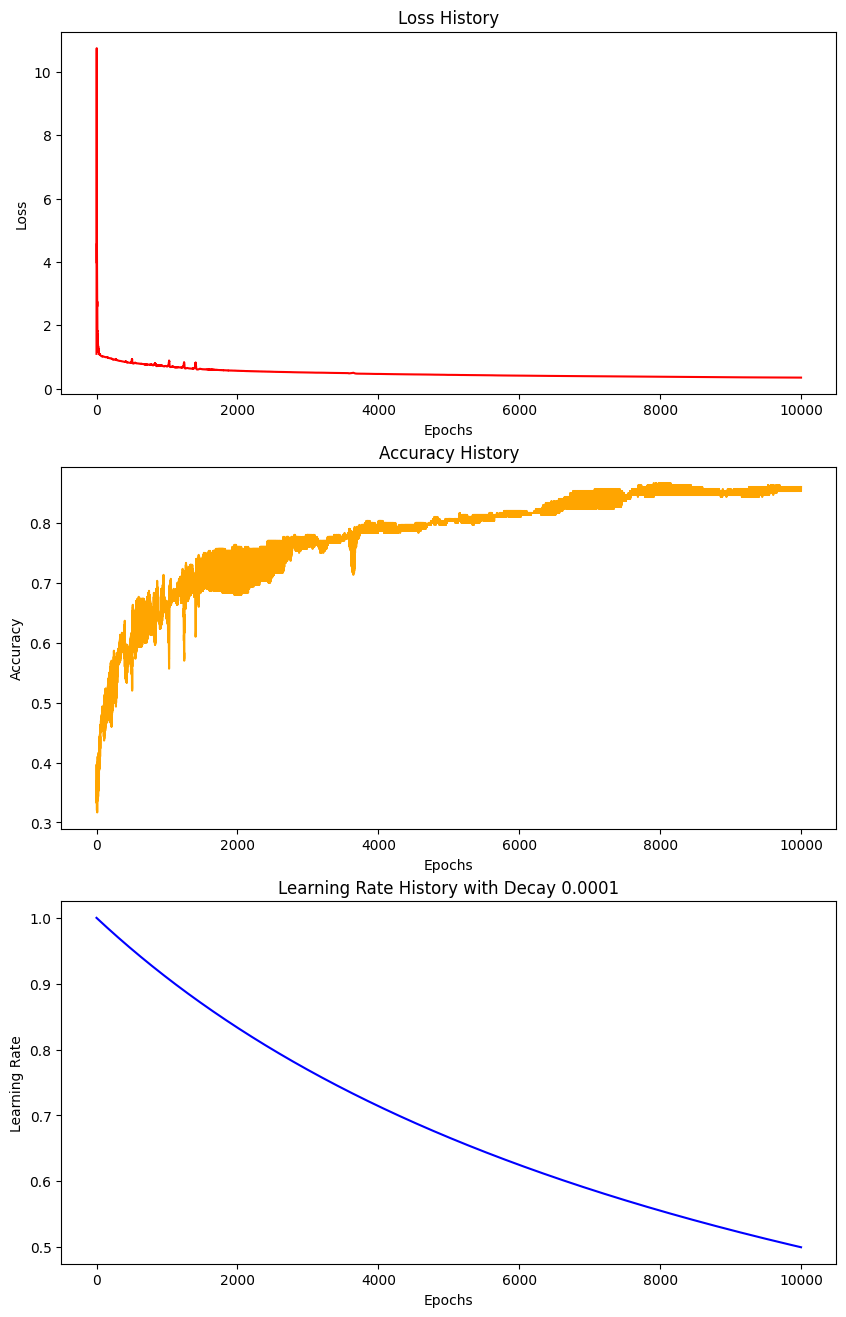

In [22]:
fig, axes = plt.subplots(nrows=3, figsize=(10, 16))

axes[0].set_title("Loss History")
axes[0].plot(loss_history, color="red")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")

axes[1].set_title("Accuracy History")
axes[1].plot(accuracy_history, color="orange")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")

axes[2].set_title(f"Learning Rate History with Decay {decay}")
axes[2].plot(learning_rate_history, color="blue")
axes[2].set_xlabel("Epochs")
axes[2].set_ylabel("Learning Rate")

print(f"Final Values: Loss {loss_history[-1]} Accuracy {accuracy_history[-1]} Learning Rate {learning_rate_history[-1]}")
print(f"Learning Rate {learning_rate} Decay {decay}")